# Mupliple Linear Regression

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("economic_index.csv")
df.drop(columns=["Unnamed: 0", "year", "month"], inplace=True)
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


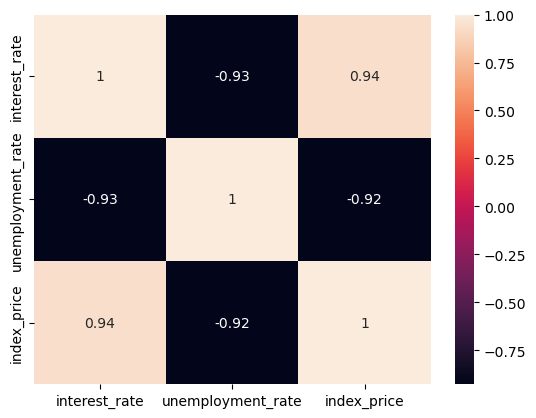

In [29]:
sns.heatmap(df.corr(), annot= True)
df.corr()

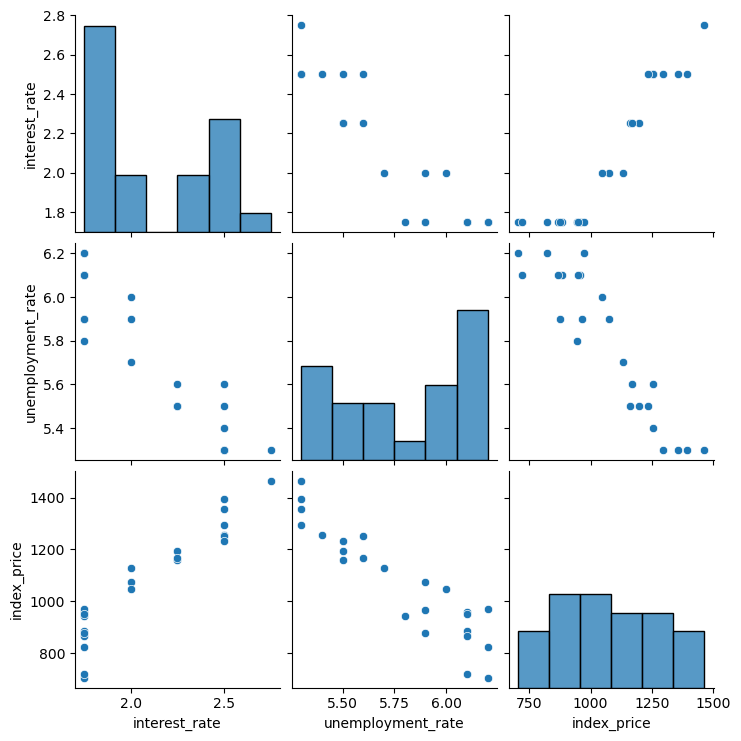

In [30]:
sns.pairplot(df)

In [31]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [32]:
# visualize

# plt.scatter(df["interest_rate"], df["unemployment_rate"], color="r")

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Feature matrix and target vector
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


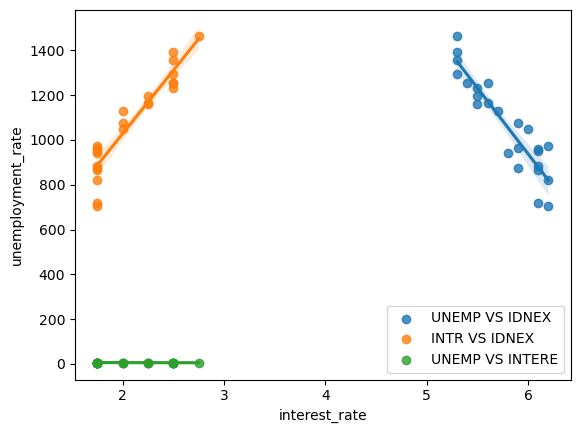

In [34]:
sns.regplot(x = df["unemployment_rate"], y= df["index_price"], label="UNEMP VS IDNEX")
sns.regplot(x = df["interest_rate"], y= df["index_price"], label="INTR VS IDNEX")
sns.regplot(x = df["interest_rate"], y= df["unemployment_rate"], label="UNEMP VS INTERE")
# regplot x and y inpu tmust be one d
plt.legend()



In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 1: Train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Step 2: Make predictions
y_pred = model.predict(X_test_scaled)

# Step 3: Evaluate performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Step 4: Output results
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)
n = X_test.shape[0]  # number of data points
p = X_test.shape[1]  # number of features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R² Score:", adjusted_r2)



Coefficients: [  86.63351334 -114.04857249]
Intercept: 1059.4210526315792
MSE: 6957.10530325883
RMSE: 83.40926389351982
R² Score: 0.8254940547158576
Adjusted R² Score: 0.6509881094317151


## Cross validation model

In [36]:
from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(model, X_train_scaled, y_train, scoring="neg_mean_squared_error", cv=3)
-validation_score.mean()

rmse = (-validation_score.mean())**0.5
print("RMSE:", rmse)

RMSE: 75.32616854179408


### Assumptions

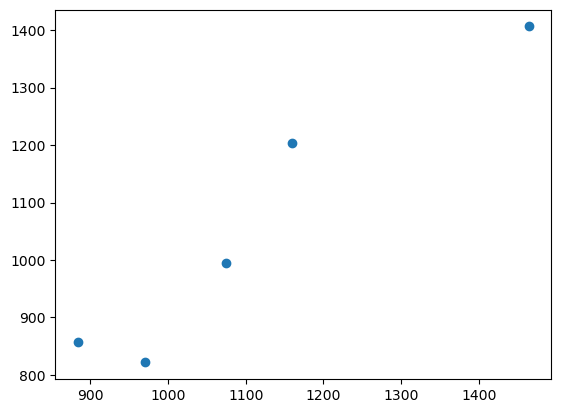

In [ ]:
plt.scatter(y_test, y_pred) # linear

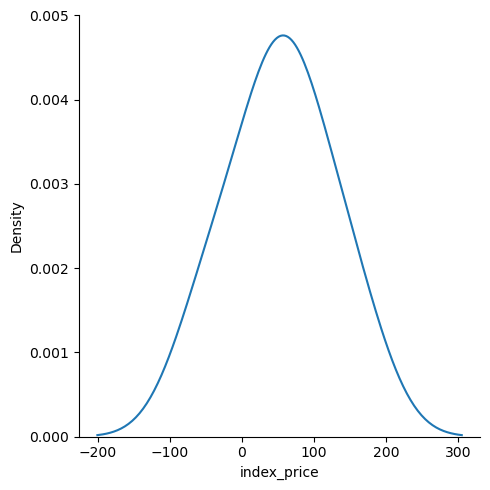

In [ ]:
residuals = y_test - y_pred
sns.displot(residuals, kind="kde") # nirmal distribution curve

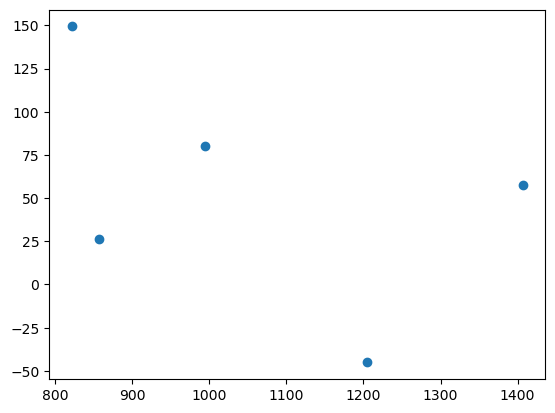

In [ ]:
# scatter plot with residuals and prediction
plt.scatter(y_pred, residuals) # uniformly distributerd